<a href="https://colab.research.google.com/github/AditiNayak-S/MLT3011_Cloud-Infrastructure-Failure-Prediction/blob/main/notebooks/Machine_LearningTechniques_Lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Techniques

## Lab 7: K-Means and Hierarchical Clustering

### Lab Objectives

- Prepare a cloud infrastructure monitoring dataset for unsupervised learning.
- Apply K-Means and Hierarchical Clustering algorithms.
- Evaluate clustering quality using the Silhouette Score.
- Visualize the generated clusters using Principal Component Analysis (PCA).
- Interpret the characteristics of the identified cloud infrastructure clusters.

## Importing Required Libraries

The following libraries are required for data preprocessing, clustering, dimensionality reduction, visualization, and clustering performance evaluation.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import zipfile

from google.colab import files

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram

plt.style.use("dark_background")

plt.rcParams["figure.figsize"]=(8,5)
plt.rcParams["font.size"]=11
plt.rcParams["axes.grid"]=True

print("Libraries imported successfully.")

Libraries imported successfully.


## Uploading Dataset B

The OpenStack cloud infrastructure dataset is uploaded and extracted. Since clustering is an unsupervised learning technique, only the engineered feature dataset is used for analysis.

In [ ]:
uploaded=files.upload()

Saving CIFPS - DATASET B.zip to CIFPS - DATASET B.zip


In [ ]:
uploaded_files = list(uploaded.keys())

for file in uploaded_files:
    with zipfile.ZipFile(file,"r") as zip_ref:
        zip_ref.extractall()

print("Dataset extracted successfully.")

Dataset extracted successfully.


## Loading the Feature Dataset

The deployment feature dataset extracted from OpenStack logs is selected for clustering analysis. The failure labels are intentionally excluded because clustering is performed without prior class information.

In [ ]:
DATASET_B_PATH="Failure-Dataset-OpenStack-main"

feature_file=os.path.join(
    DATASET_B_PATH,
    "DEPL",
    "LCS_with_VMM.tsv"
)

X=pd.read_csv(
    feature_file,
    sep="\t"
)

print("Dataset Shape :",X.shape)

display(X.head())

Dataset Shape : (1076, 208)


,cinderclient_DELETE_202,cinderclient_DELETE_400,cinderclient_DELETE_500,cinderclient_GET_200,cinderclient_GET_400,cinderclient_GET_404,cinderclient_GET_500,cinderclient_POST_200,cinderclient_POST_202,cinderclient_POST_400,...,q-plugin_get_ports.1,q-plugin_release_dhcp_port.1,q-plugin_update_device_list.1,q-plugin_update_device_list_ERROR.1,scheduler_delete_instance_info.1,scheduler_delete_instance_info_ERROR.1,scheduler_select_destinations.1,scheduler_select_destinations_ERROR.1,scheduler_update_instance_info.1,scheduler_update_instance_info_ERROR.1
0,0,0,0,0,0,0,0,0,0,0,...,13,0,1,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,15,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,7,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,7,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,4,0,1,0,0,0,0,0,0,0


## Feature Standardization

K-Means and Hierarchical Clustering are distance-based algorithms. Therefore, feature standardization is performed to ensure that all cloud monitoring features contribute equally during clustering.

In [ ]:
scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

print("Feature standardization completed.")

print("Scaled Dataset Shape :",X_scaled.shape)

Feature standardization completed.
Scaled Dataset Shape : (1076, 208)


## Why Clustering?

Clustering is an unsupervised machine learning technique that groups similar observations based on their feature characteristics. Unlike classification, clustering does not require predefined labels and instead discovers natural patterns within the cloud infrastructure monitoring data.

## Determining the Optimal Number of Clusters

Before applying K-Means clustering, the Elbow Method is used to estimate an appropriate number of clusters. The Within-Cluster Sum of Squares (WCSS) is computed for different values of K to observe how clustering compactness changes.

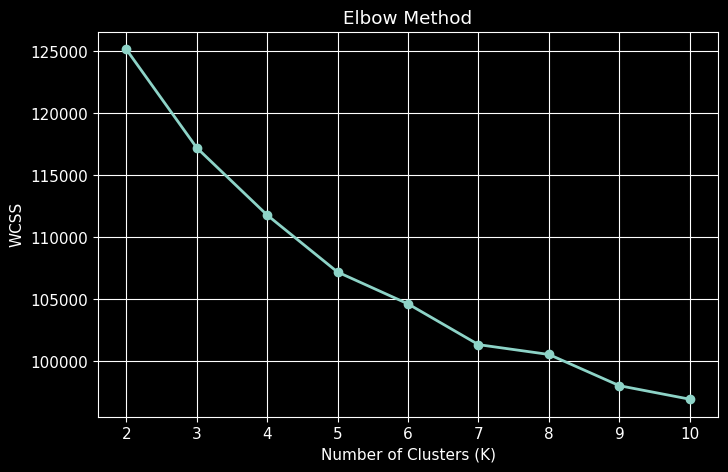

In [ ]:
wcss = []

k_values = range(2, 11)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    wcss,
    marker="o",
    linewidth=2
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("WCSS")

plt.xticks(k_values)

plt.show()

## K-Means Clustering

Based on the Elbow Method and the known operational categories within the dataset, K-Means clustering is performed using six clusters to group similar cloud infrastructure behaviour patterns.

In [ ]:
kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed.")

K-Means clustering completed.


## Hierarchical Clustering

Hierarchical Clustering groups observations by progressively merging similar clusters. Unlike K-Means, it does not rely on randomly initialized cluster centers and produces a hierarchical tree structure.

In [ ]:
hierarchical = AgglomerativeClustering(
    n_clusters=6
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

print("Hierarchical clustering completed.")

Hierarchical clustering completed.


## Clustering Evaluation

The Silhouette Score measures how well observations fit within their assigned clusters. Higher values indicate better separation between clusters.

In [ ]:
kmeans_score = silhouette_score(
    X_scaled,
    kmeans_labels
)

hierarchical_score = silhouette_score(
    X_scaled,
    hierarchical_labels
)

evaluation = pd.DataFrame({
    "Algorithm":[
        "K-Means",
        "Hierarchical Clustering"
    ],
    "Silhouette Score":[
        round(kmeans_score,4),
        round(hierarchical_score,4)
    ]
})

display(evaluation)

,Algorithm,Silhouette Score
0,K-Means,0.2412
1,Hierarchical Clustering,0.2597


## Principal Component Analysis (PCA)

Principal Component Analysis reduces the high-dimensional feature space into two principal components. These components are used only for visualization, enabling the discovered clusters to be displayed in two dimensions.

In [ ]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=[
        "PC1",
        "PC2"
    ]
)

pca_df["KMeans"] = kmeans_labels
pca_df["Hierarchical"] = hierarchical_labels

display(pca_df.head())

,PC1,PC2,KMeans,Hierarchical
0,-2.846215,0.926049,2,4
1,-3.348373,0.722095,2,4
2,-3.146336,0.844886,2,4
3,-2.867571,1.173436,2,4
4,-3.034321,0.627701,2,4


## K-Means Cluster Visualization

The following scatter plot illustrates the clusters identified by the K-Means algorithm after reducing the dataset to two principal components.

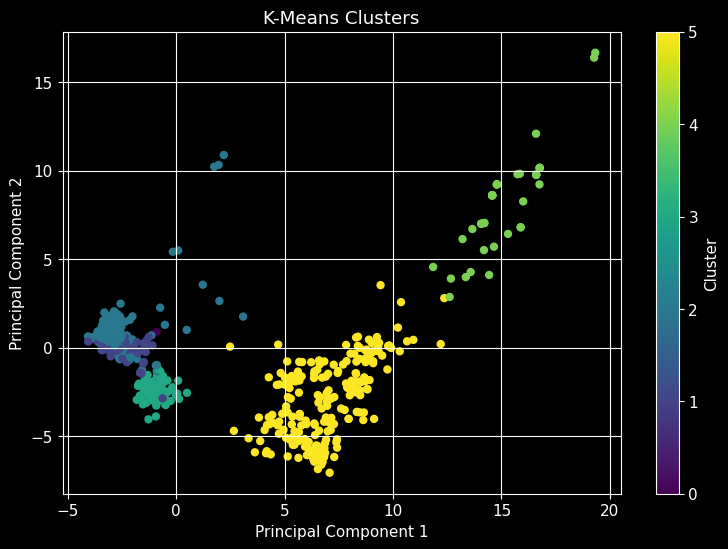

In [ ]:
plt.figure(figsize=(9,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["KMeans"],
    cmap="viridis",
    s=25
)

plt.title("K-Means Clusters")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

## Hierarchical Cluster Visualization

The following visualization displays the clusters generated by Hierarchical Clustering using the same PCA representation.

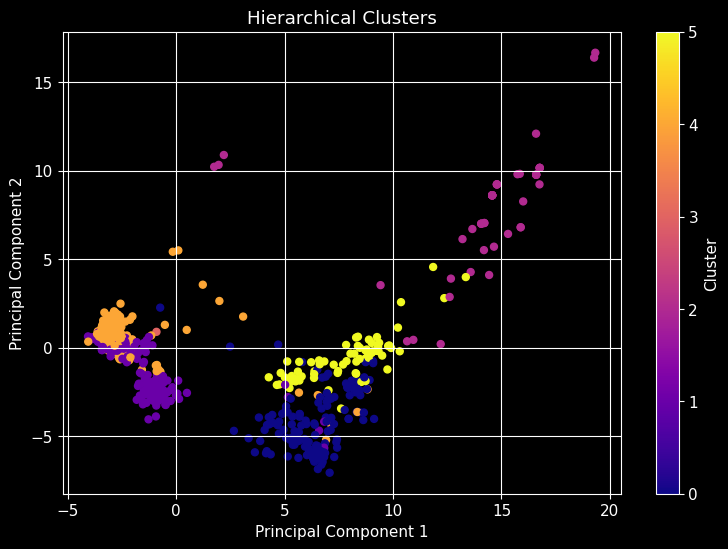

In [ ]:
plt.figure(figsize=(9,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Hierarchical"],
    cmap="plasma",
    s=25
)

plt.title("Hierarchical Clusters")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

## Hierarchical Dendrogram

The dendrogram represents the hierarchical relationships between observations. It illustrates how clusters are progressively merged based on similarity.

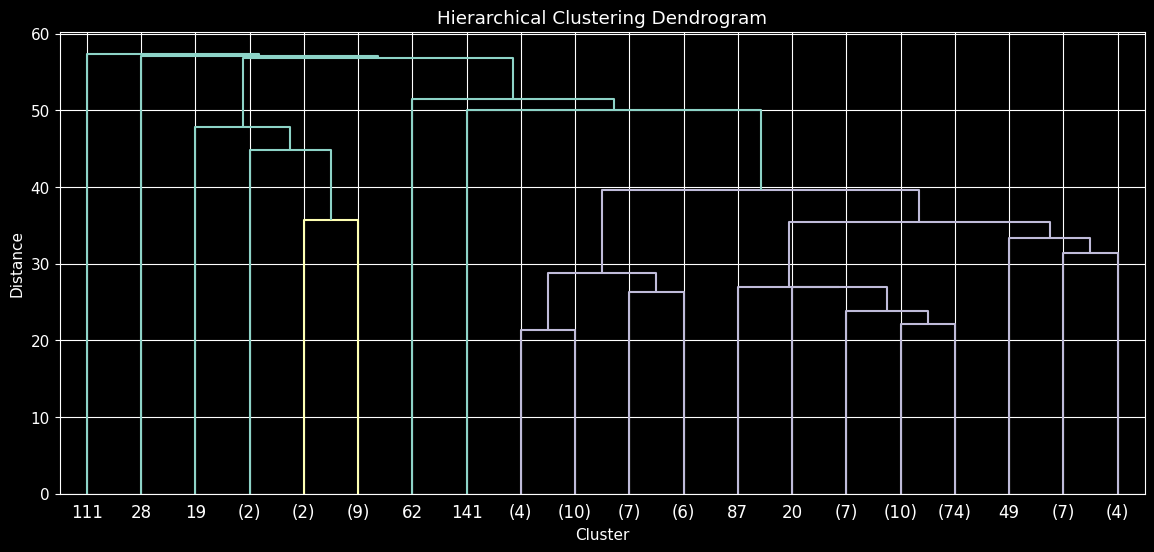

In [ ]:
sample_size = 150

linked = linkage(
    X_scaled[:sample_size],
    method="ward"
)

plt.figure(figsize=(14,6))

dendrogram(
    linked,
    truncate_mode="lastp",
    p=20
)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Cluster")

plt.ylabel("Distance")

plt.show()

## Cluster Size Distribution

The following chart shows the number of observations assigned to each cluster by the K-Means algorithm.

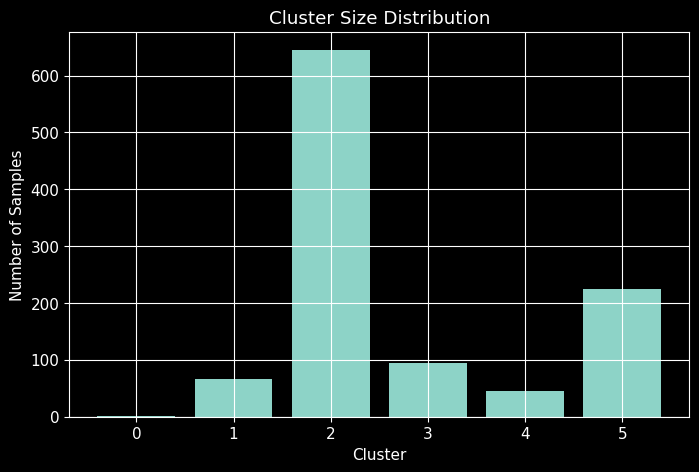

In [ ]:
cluster_sizes = pd.Series(
    kmeans_labels
).value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(
    cluster_sizes.index.astype(str),
    cluster_sizes.values
)

plt.title("Cluster Size Distribution")

plt.xlabel("Cluster")

plt.ylabel("Number of Samples")

plt.show()

## Clustering Performance Comparison

The Silhouette Score provides a quantitative comparison of the clustering quality achieved by K-Means and Hierarchical Clustering.

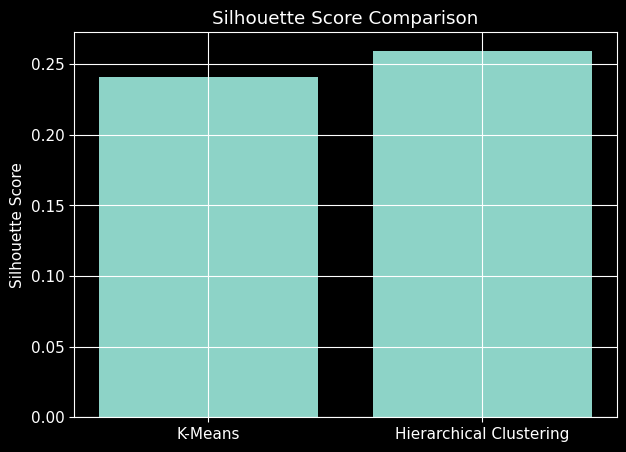

In [ ]:
plt.figure(figsize=(7,5))

plt.bar(
    evaluation["Algorithm"],
    evaluation["Silhouette Score"]
)

plt.title("Silhouette Score Comparison")

plt.ylabel("Silhouette Score")

plt.show()

## Cluster Interpretation

The clustering algorithms successfully grouped cloud infrastructure monitoring records based on similarities in their operational behaviour. K-Means partitions the observations around centroid locations, whereas Hierarchical Clustering progressively merges similar observations into larger groups. The PCA visualizations and Silhouette Scores provide insight into the separation and cohesion of the identified clusters.

## Conclusion

In this laboratory experiment, K-Means and Hierarchical Clustering were successfully applied to a real-world OpenStack cloud infrastructure dataset. Feature standardization ensured fair distance-based clustering, while the Elbow Method guided the selection of the number of clusters. Principal Component Analysis enabled two-dimensional visualization of the high-dimensional data, and the Silhouette Score was used to evaluate clustering quality. The experiment demonstrated how unsupervised learning can uncover meaningful operational patterns within cloud infrastructure monitoring data.

In [ ]:
checklist = pd.DataFrame({
    "Task":[
        "Loaded Dataset B",
        "Standardized features",
        "Applied Elbow Method",
        "Implemented K-Means",
        "Implemented Hierarchical Clustering",
        "Calculated Silhouette Scores",
        "Applied PCA for visualization",
        "Generated clustering visualizations",
        "Interpreted clusters",
        "Completed experiment"
    ],
    "Status":["✓ Completed"]*10
})

display(checklist)

,Task,Status
0,Loaded Dataset B,✓ Completed
1,Standardized features,✓ Completed
2,Applied Elbow Method,✓ Completed
3,Implemented K-Means,✓ Completed
4,Implemented Hierarchical Clustering,✓ Completed
5,Calculated Silhouette Scores,✓ Completed
6,Applied PCA for visualization,✓ Completed
7,Generated clustering visualizations,✓ Completed
8,Interpreted clusters,✓ Completed
9,Completed experiment,✓ Completed
